In [1]:
import os
os.environ["PATH"] = "/Library/TeX/texbin:/opt/homebrew/bin:" + os.environ["PATH"]

import pickle
import numpy as np

import matplotlib.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm, gridspec
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize

import scipy.stats as stats
from scipy.interpolate import PchipInterpolator

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import fitz

import model_misc_Gerardo as mm
from functions_library import *
from functions_Figures_main import *

plt.rcParams['axes.unicode_minus'] = True
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for text rendering
    "font.family": "serif",  # Match LaTeX font
    "font.size": 12,        # Adjust font size
    "axes.labelsize": 18,   # Axis labels size
    "legend.fontsize": 13,  # Legend font size
    "axes.titlesize": 23,
    "xtick.labelsize": 13,  # X-axis tick size
    "ytick.labelsize": 13,  # Y-axis tick size
})

In [2]:
# Fecth all dataset names
all_dfs = ['bibsonomy', 'edit_wiktionary/mg', 'escorts', 'movielens_100k', 'citeulike', 'sp_infectious', 'edit_wiktionary/fr', 'wiki_link_dyn', 'edit_wiktionary/en', 'lastfm/song', 'wikiconflict', 'facebook_wall', 'contact', 'email_company', 'lkml_reply', 'sp_primary_school', 'sp_colocation/SFHH', 'sp_colocation/InVS15', 'sp_colocation/InVS13', 'sp_colocation/LH10', 'lastfm/band', 'edit_wikibooks/de', 'edit_wikibooks/fr', 'sp_high_school/proximity', 'sp_colocation/Thiers13', 'wiki_talk/fr', 'wiki_talk/de', 'sp_hypertext/contacts', 'sp_high_school_new/2011', 'wiki_talk/en', 'sp_office', 'edit_wikibooks/en', 'sp_high_school_new/2012', 'reality_mining', 'lkml_thread', 'sp_colocation/LyonSchool', 'sp_hospital', 'edit_wikinews/en', 'edit_wikinews/it']

In [3]:
# Import the basic statistics of each dataset

with open(f'./mean_std_IET.pkl', 'rb') as f: #IET info (system-wide edge-level IET): mean and std
    dataset_names, mean_iet, std_iet = pickle.load(f)

with open(f'./mean_node_IET.pkl', 'rb') as f: #IET info (system-wide node-level IET): mean and std
    all_dfs, node_iet = pickle.load(f)
    
with open(f'./mean_std_degree.pkl', 'rb') as f: #degree info: mean and std
    (dataset_names, mean_ks, std_ks) = pickle.load(f)

with open('./two_dimensions.pkl', 'rb') as f: # system-wide, edge0-level burstiness and openness
    (dataset_names, its_s_burstiness, ks_stats) = pickle.load(f)

# get the openness 
l1_means, datasets_open, datasets_closed, burstiness_open, burstiness_closed = get_openness(dataset_names, 'edge', its_s_burstiness) #at the edge-level
l1_means_node, datasets_open_node, datasets_closed_node, _, _ = get_openness(dataset_names, 'node', its_s_burstiness) #at the node-level

In [4]:
# Assign a color to each dataset based on the burstiness

# create the custom colormap
colors_blue = ["#121249","#24248B","#2E3F9E","#154D92","#1567A5","#3A88C4","#A5CDEB"]
cmap_blue = mcolors.LinearSegmentedColormap.from_list("blue_part", colors_blue)
colors_orange = ["#EFAB5D", "#E18025","#E06513","#C24228","#47240A"]
cmap_orange = mcolors.LinearSegmentedColormap.from_list("orange_part", colors_orange)
norm = mcolors.Normalize(vmin=0, vmax=1)
cmap_blue_orange = combine_two_colormaps(cmap_blue, cmap_orange)

# assign a color from the colormap to each dataset based on their burstiness index (its_s_burstiness)
colors = []
for iter_dataset, dataset_name in enumerate(all_dfs):
    colors.append(get_color(its_s_burstiness[iter_dataset], norm, cmap_blue_orange))

In [5]:
MAX_windows = 1000

## Figure 1

In [6]:
overlap = 0.2

/Users/pkt949/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/pkt949/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/pkt949/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


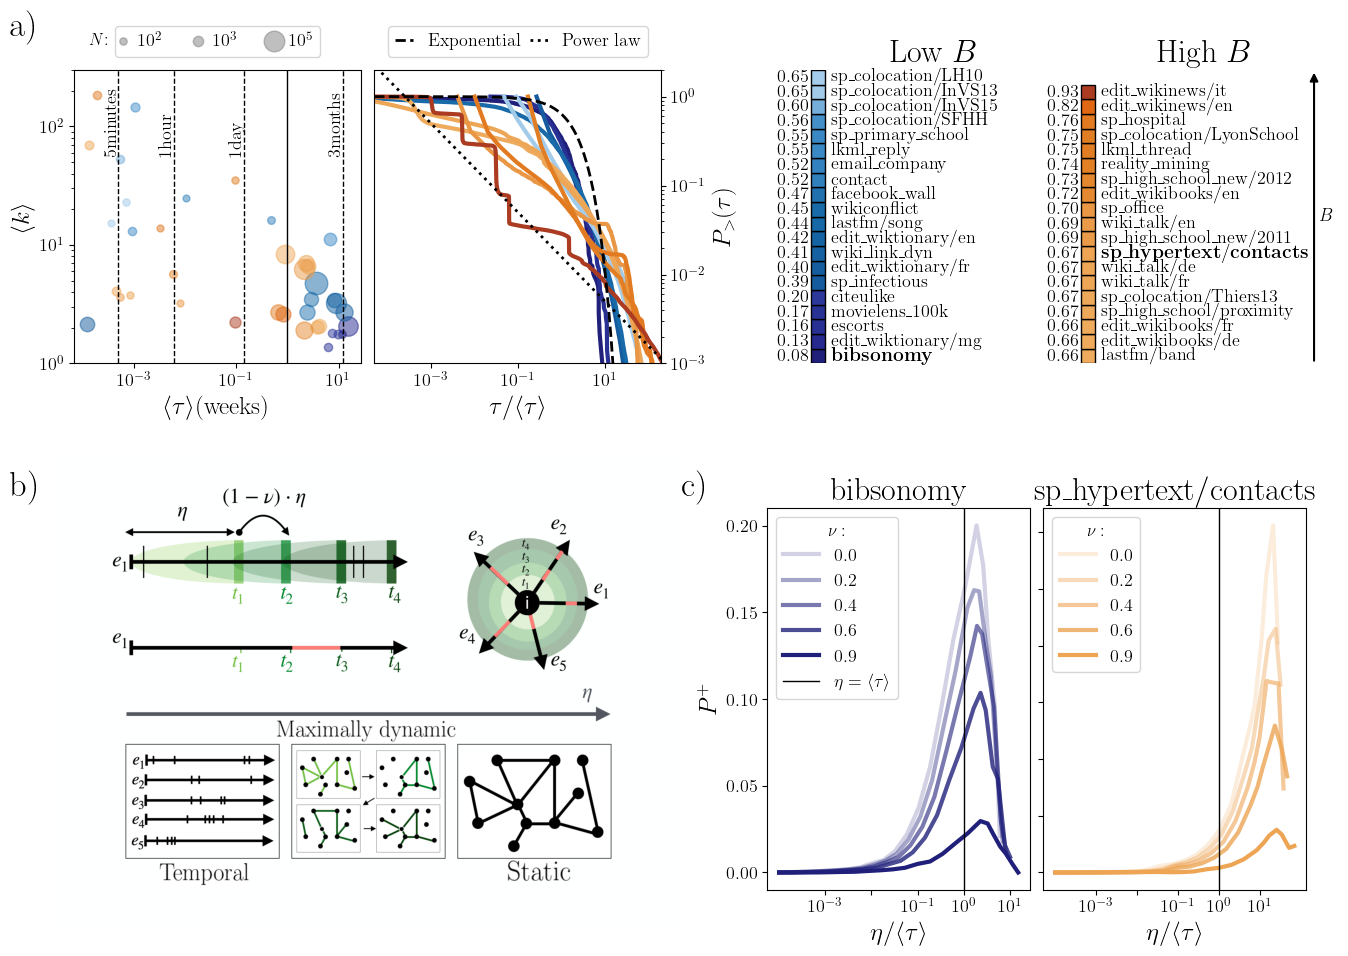

In [7]:
fig = plt.figure(figsize=(16, 10))

outer_gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1.3], wspace=0.3, hspace=0.28) #

## PANEL A: datasets
panel_a_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0, 0], wspace=0.05) # layout with two side-by-side columns

# set the position of the two sub-panels
# left sub-panel
bbox = panel_a_gs[0, 0].get_position(fig)
ax_a1 = fig.add_axes([bbox.x0, bbox.y0, bbox.width, bbox.height])
# right sub-panel
bbox = panel_a_gs[0, 1].get_position(fig)
ax_a2 = fig.add_axes([bbox.x0, bbox.y0, bbox.width, bbox.height])
ax_a2.yaxis.tick_right()
ax_a2.yaxis.set_label_position("right")

which_datasets = [0, 5, 10, 18, 20, 25, 30, 35, 18, 36, 19, 2, 38] # choice of the 13 datasets
for iter_data, dataset_name in enumerate(all_dfs):
    dataset_name = dataset_name.replace("/", "_")
    filename = f'./data/{dataset_name}/{dataset_name}_edge_interevents.pkl'

    # get mean IET
    with open(filename, "rb") as file:
        input_dict = pickle.load(file)
    mean_tau, _ = means_stds_from_dict(input_dict) 

    # get mean degree and system size
    filename = f'./data/{dataset_name}/{dataset_name}_node_degrees.pkl'
    input_dict = {}
    with open(filename, "rb") as file:
        input_dict = pickle.load(file)
    mean_k, _ = means_stds_from_dict(input_dict) 
    size = len(input_dict)**(0.3)*7

    # Left sub-panel
    if dataset_name != 'escorts':
        ax_a1.scatter(mean_tau[1]/(60*60*24*7), mean_k, color = colors[iter_data], s = size, alpha = 0.5) 
    else:
        ax_a1.scatter(mean_tau[1]/(7), mean_k, color = colors[iter_data], s = size, alpha = 0.5)

    # Right sub-panel
    if iter_data in which_datasets:
        filename = f"./data/{dataset_name}/{dataset_name}_ccdf_edge_interevents.pkl"
        with open(filename, "rb") as file:
            data = pickle.load(file)
        cdf_x_values = data[:, 0]
        ccdf_vals = data[:, 1]

        my_plot(ax_a2, cdf_x_values/mean_tau[1], ccdf_vals, r'$\tau / \langle \tau \rangle$', r'$\Psi(\tau)$', colors[iter_data], '', linestyle='-', my_xscale = 'log', my_yscale = 'log')

# figure adjustments left sub-panel
# system size legend
smin = 100 
smax = 100000 
smid = 1000 
for i, s in enumerate([smin, smid, smax]):
    ax_a1.scatter([], [], s=s**(0.3)*7, label=fr"${legend_format(s)}$" if i == 0 else fr"${legend_format(s)}$", color = 'grey', alpha = 0.5)  
ax_a1.legend(loc = 'upper center', handlelength=0.05, columnspacing=2, bbox_to_anchor=(0.5, 1.18), ncol = 3) #, title = 'N:')
ax_a1.text(0.12, 1.1, r"$N$:", transform=ax_a1.transAxes, ha="right", va="center")

# relevant timescales
ax_a1.axvline(x = 1, color = 'k', lw = 1)
lines = [5/(60*24*7), 1/(24*7), 1/(7), 4*3]
labels = [r"$\rm{5 minutes}$", r"$\rm{1 hour}$", r"$\rm{1 day}$", r"$\rm{3 months}$"]
for x, text in zip(lines, labels):
    ax_a1.axvline(x=x, color='black', linewidth=1, linestyle = '--')
    trans = ax_a1.get_xaxis_transform()
    text_offset = transforms.ScaledTranslation(11/72,0,fig.dpi_scale_trans)
    ax_a1.text(x, 0.7, text,rotation=90,va='bottom',ha='left',transform=trans - text_offset, fontsize=13)

ax_a1.set_ylim([1, 300])
ax_a1.set_yscale('log')
ax_a1.set_xscale('log')
ax_a1.set_ylabel(r'$\langle k \rangle$')
ax_a2.set_ylabel(r'$P_{>}(\tau)$')
ax_a1.set_xlabel(r'$\langle \tau \rangle \rm{(weeks)}$')
ax_a2.set_xlabel(r'$\tau / \langle \tau \rangle$')
ax_a2.tick_params(axis='both')
ax_a1.tick_params(axis='both')

# figure adjustments right sub-panel
# guides for the eye
x = np.logspace(np.log10(1e-6), np.log10(4000), num=1000)
y1 = np.exp(-0.45*x)
ax_a2.set_ylim([0.001, 2])
x_limits = ax_a2.get_xlim()
ax_a2.set_xlim([0.00005, 200])
y2 = 1/x**(0.5)*10**(-1.8)
ax_a2.plot(x, y1, color = 'k', linestyle = '--', label = r'$\rm{Exponential}$', lw = 2)
ax_a2.plot(x, y2, color = 'k', linestyle = ':', label = r'$\rm{Power}$ $\rm{law}$', lw = 2)
ax_a2.legend(loc = 'upper center', bbox_to_anchor=(0.5, 1.18), ncol = 2, columnspacing=0.5, handlelength=1)

# overall adjustment
pos = ax_a1.get_position()  
ax_a1.set_position([pos.x0, 0.93 - pos.height, pos.width, pos.height])
pos = ax_a2.get_position()  
ax_a2.set_position([pos.x0, 0.93 - pos.height, pos.width, pos.height])

pos1 = ax_a1.get_position()
pos2 = ax_a2.get_position()
expand = 0.015 
ax_a1.set_position([pos1.x0 - expand, pos1.y0, pos1.width + expand, pos1.height])
ax_a2.set_position([pos2.x0, pos2.y0, pos2.width + expand, pos2.height])

## PANEL A bis: dataset names and their burstiness
panel_c_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0, 1]) # two side-by-side panels

# set the position of the two sub-panels
# left sub-panel
bbox = panel_c_gs[0, 0].get_position(fig)
ax_c_closed = fig.add_axes([bbox.x0, bbox.y0-0.07, bbox.width, bbox.height])
# right sub-panel
bbox = panel_c_gs[0, 1].get_position(fig)
ax_c_open = fig.add_axes([bbox.x0, bbox.y0-0.07, bbox.width, bbox.height])
ax_c_closed.axis("off")
ax_c_open.axis("off")

# burstiness arrow
ax_c_open.annotate('', xy=(0.91, ax_c_open.get_ylim()[1]), xytext=(0.91, ax_c_open.get_ylim()[0]), arrowprops=dict(facecolor='black', arrowstyle='-|>', linewidth=1.5))
ax_c_open.text(0.93, (ax_c_open.get_ylim()[0] + ax_c_open.get_ylim()[1]) / 2, r'$B$', va='center', ha='left', fontsize=13, fontweight='bold')

# get the two burstiness groups
bursty = [d for i, d in enumerate(dataset_names) if its_s_burstiness[i] > np.median(its_s_burstiness)]
poissonian = [d for i, d in enumerate(dataset_names) if its_s_burstiness[i] <= np.median(its_s_burstiness)]

y_square_size = 1/len(poissonian)
x_square_size = y_square_size
# left subplot
for i, name in enumerate(poissonian):
    y = i * y_square_size
    idx = dataset_names.index(name)
    color = colors[idx]

    ax_c_closed.add_patch(Rectangle((x_square_size*0.9, y), x_square_size, y_square_size, facecolor=color, edgecolor="black", linewidth=1))
    if name != 'bibsonomy': # highlight the bibsonomy dataset (relevant for panel c)
        ax_c_closed.text(x_square_size*1.3 + x_square_size + x_square_size/10, y + y_square_size/2, name, va="center", ha="left", fontsize=13)
    else:
        safe_name = name.replace("_", r"\_")
        name = rf"$\mathbf{{{safe_name}}}$"
        ax_c_closed.text(x_square_size*1.3 + x_square_size + x_square_size/10, y + y_square_size/2, name, va="center", ha="left", fontsize=14, fontweight = 'bold')
    ax_c_closed.text(-x_square_size/2, y + y_square_size/2, f"{its_s_burstiness[idx]:.2f}", color="k", fontsize=13, ha="center", va="center", fontweight="bold")

# right subplot
for i, name in enumerate(bursty):
    y = i * y_square_size
    idx = dataset_names.index(name)
    color = colors[idx]

    ax_c_open.add_patch(Rectangle((x_square_size*0.9, y), x_square_size, y_square_size, facecolor=color, edgecolor="black", linewidth=1))
    if name != 'sp_hypertext/contacts': # highlight the sp_hypertext_contacts dataset (relevant for panel c)
        ax_c_open.text(x_square_size*1.3 + x_square_size + x_square_size/10, y + y_square_size/2,name, va="center", ha="left", fontsize=13)
    else:
        safe_name = name.replace("_", r"\_")
        name = rf"$\mathbf{{{safe_name}}}$"
        ax_c_open.text(x_square_size*1.3 + x_square_size + x_square_size/10, y + y_square_size/2, name, va="center", ha="left", fontsize=14, fontweight="bold")
    ax_c_open.text(-x_square_size/2, y + y_square_size/2, f"{its_s_burstiness[idx]:.2f}", color="k", fontsize=13, ha="center", va="center", fontweight="bold")

# adjustments and titles
pos = ax_c_open.get_position()  
ax_c_open.set_position([pos.x0, 0.93 - pos.height, pos.width, pos.height])
pos = ax_c_closed.get_position()  
ax_c_closed.set_position([pos.x0, 0.93 - pos.height, pos.width, pos.height])
ax_c_closed.set_title(r'$\mathrm{Low}$ $B$')
ax_c_open.set_title(r'$\mathrm{High}$ $B$')

pos1 = ax_c_open.get_position()
pos2 = ax_c_closed.get_position()
expand = 0.015 
ax_c_open.set_position([pos1.x0 - expand, pos1.y0, pos1.width + expand, pos1.height])
ax_c_closed.set_position([pos2.x0, pos2.y0, pos2.width + expand, pos2.height])

# panel tag: a
fig.text(0.07, 0.99, r"$\rm{a)}$", fontsize=25, va='top')

### PANEL B: schematic
bbox = outer_gs[1, 0].get_position(fig)
ax_b = fig.add_axes([bbox.x0-0.025, bbox.y0-0.04, bbox.width+0.05, bbox.height+0.09])

# import the pdf schematic
pdf_path = "./diagramme_aggregation.pdf"
doc = fitz.open(pdf_path)
page = doc.load_page(0) 

zoom = 400 / 72  # high resolution
mat = fitz.Matrix(zoom, zoom)
pix = page.get_pixmap(matrix=mat)

img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)

ax_b.imshow(img, aspect='auto')
ax_b.axis('off')  # remove axes

# panel tag: b
fig.text(0.07, 0.53, r"$\rm{b)}$", fontsize=25, va='top')

## PANEL C: Activation probability
panel_d_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[1, 1], wspace=0.05) # two side-by-side sub-panels

#left sub-panel
bbox = panel_d_gs[0, 0].get_position(fig)
ax_d2_left = fig.add_axes([bbox.x0-0.02, bbox.y0, bbox.width, bbox.height])
# right sub-panel
bbox = panel_d_gs[0, 1].get_position(fig)
ax_d2_right = fig.add_axes([bbox.x0-0.02, bbox.y0, bbox.width, bbox.height])

# left sub-panel plot
overlaps = [0.0, 0.2, 0.4, 0.6, 0.9] # choice of overlaps considered
which = 0 # index of the bibsonomy dataset in all_dfs
for overlap in overlaps:
    get_plot_pplus(which, ax_d2_left, overlap, colors, all_dfs, lw = 3, mean_iet = mean_iet, MAX_windows=MAX_windows) 

# left title
name = all_dfs[which]
safe_name = name.replace("_", r"\_")
name = rf"$\rm{{{safe_name}}}$"
ax_d2_left.set_title(name)

# legend and axes labels
ax_d2_left.plot([], [], color = 'k', lw = 1, label = r'$\eta = \langle \tau \rangle$')
leg = ax_d2_left.legend(title = rf'$\nu:$')
ax_d2_left.axvline(x = 1, color = 'k', lw = 1)
ax_d2_left.set_xlabel(r"$\eta/ \langle \tau \rangle$")
ax_d2_left.set_ylabel(r"$P^+$")

# ticks
ticks = np.linspace(0, 0.2, 5)
ax_d2_left.set_yticks(ticks)
ticks = np.logspace(-3, 1, 5)  
ax_d2_left.set_xticks(ticks)
labels = [r"$10^{-3}$", "", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$",]
ax_d2_left.set_xticklabels(labels)

# right sub-panel plot
which = 27 # index of the sp_hypertext_contacts dataset in all_dfs
for overlap in overlaps:
    get_plot_pplus(which, ax_d2_right, overlap, colors, all_dfs, lw = 3, mean_iet = mean_iet, MAX_windows=MAX_windows) 

# title
name = all_dfs[which]
safe_name = name.replace("_", r"\_")
name = rf"$\rm{{{safe_name}}}$"
ax_d2_right.set_title(name)

# legend and axis label
leg = ax_d2_right.legend(title = rf'$\nu:$')
ax_d2_right.set_yticklabels([])
ax_d2_right.axvline(x = 1, color = 'k', lw = 1)
ax_d2_right.set_xlabel(r"$\eta/\langle \tau \rangle$")

#ticks
ticks = np.logspace(-3, 1, 5)  
ax_d2_right.set_xticks(ticks)
labels = [r"$10^{-3}$", "", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$",]
ax_d2_right.set_xticklabels(labels)

# panel tag: c
fig.text(0.49, 0.53, r"$\rm{c)}$", fontsize=25, va='top')

# plt.savefig("workinprogress_figure1_v5.pdf", bbox_inches='tight', dpi=400)
plt.show()

## Figure 2

In [8]:
overlap = 0.2

# get the analytical expectation for a Gamma distributed IET
Bs_gamma, eta_stars_gamma = get_gamma_max_dyn_scale(40, overlap)

# get mixed approach (empirical distributions in analytical equations) eta_star (maximally dynamic scale) and eta_c (scale of emergence of LCC)
eta_stars, eta_cs = get_eta_c_and_star(all_dfs, mean_iet, overlap, mean_ks, std_ks)

eta_stars = np.array(eta_stars)
eta_cs = np.array(eta_cs)
colors = np.array(colors)

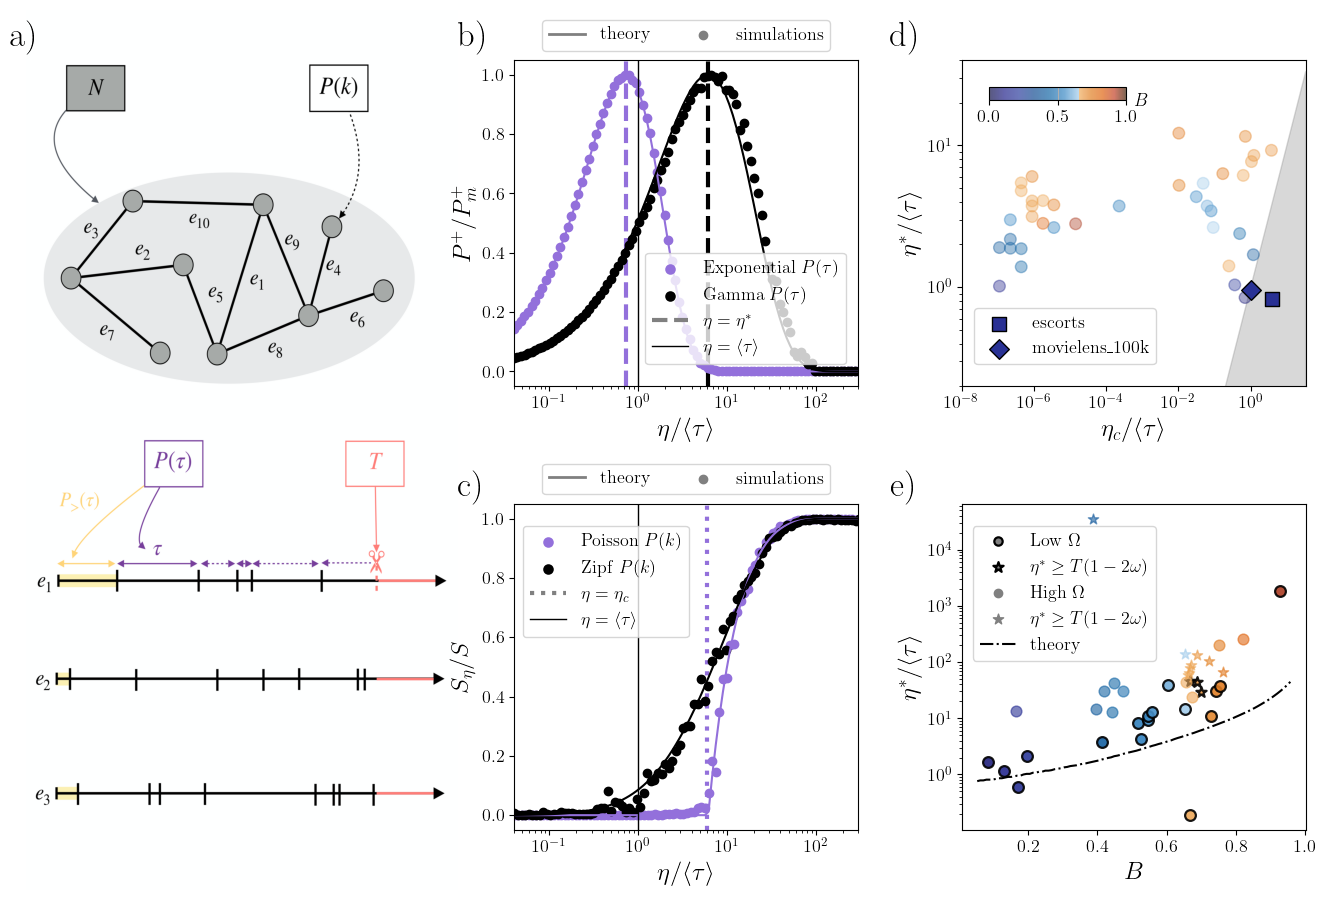

In [9]:
fig = plt.figure(figsize=(16, 10))

# Main layout: 3 columns, one row
gs = gridspec.GridSpec(nrows=1, ncols=3, wspace = 0.3)

## Panel A: coarse-graining from edge-level to node-level
ax_a = fig.add_subplot(gs[0])
ax_a.set_position([0.1, 0.05, 0.27, 0.88])  # [left, bottom, width, height]

# get the model diagramme
pdf_path = "./updates-stationary.pdf" 
doc = fitz.open(pdf_path)
page = doc.load_page(0) 
zoom = 400/ 72  # high resolution
mat = fitz.Matrix(zoom, zoom)
pix = page.get_pixmap(matrix=mat)
img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
ax_a.imshow(img, aspect='auto')
ax_a.axis('off') 

# panel tag: a
fig.text(0.09, 0.92, r"$\rm{a)}$", fontsize=25, va='top')

# second/middle column
# two rows
gs_left = gs[1].subgridspec(nrows=2, ncols=1, hspace=0.36)

## panel B: maximally dynamic scale (analytical)
ax_bL = fig.add_subplot(gs_left[0, 0])

# homogeneous IET case
prms_homo = {
    'ovl_frac' : 0.2, #overlap (as fraction of window length)
    'iet_dist' : stats.expon(scale = 2.5),
    'iet_name' : 'expon', #IET dist name
    'niets' : 30000, #number of IETs
    'ppf' : 0.999 #ppf to define initial time offset
}
make_fig_theor_pplus(prms_homo, ax_bL, 'mediumpurple', r'num. (homog. $P(\tau)$)', my_legend = 'off')
# heterogeneous IET case
prms_hetero = {
    'ovl_frac' : 0.2, #overlap (as fraction of window length)
    'iet_dist' : stats.gamma(a = 0.05, scale = 50.), #gamma with given shape/scale
    'iet_name' : 'gamma', #IET dist name
    'niets' : 30000, #number of IETs
    'ppf' : 0.999 #ppf to define initial time offset
}
make_fig_theor_pplus(prms_hetero, ax_bL, 'k', r'num. (heterog. $P(\tau)$)', edgecolor = 'k', my_legend = 'off')

# axes labels
ax_bL.set_ylabel(r"$P^{+} / P_m^{+}$")
ax_bL.set_xlabel(r'$\eta / \langle \tau \rangle$')
ax_bL.axvline(1, color = 'k', lw = 1)

# ticks
ticks = np.logspace(-2, 2, 5)  
ax_bL.set_xticks(ticks)
labels = [r"$10^{-2}$", "", r"$10^{0}$", "", r"$10^{2}$"]
ax_bL.set_xticklabels(labels)

# legends
pink_scatter = ax_bL.scatter([], [], marker = 'o', color = 'mediumpurple', label=r'$\rm{Exponential}$ $P(\tau)$', lw = 1.6)
purple_scatter = ax_bL.scatter([], [], marker = 'o', edgecolor = 'k',  color = 'k', label=r'$\rm{Gamma}$ $P(\tau)$', lw = 1.6)
dotted_line, = ax_bL.plot([], [], color='grey', linestyle='--', lw = 3, label=r'$\eta = \eta^*$')
vertical_line, = ax_bL.plot([], [], color = 'k', lw = 1, label=r'$\eta = \langle \tau \rangle$')
leg1 = ax_bL.legend(handles=[pink_scatter, purple_scatter, dotted_line, vertical_line], loc="lower right", bbox_to_anchor=(0.99, 0.04))
ax_bL.add_artist(leg1)

theor_line, = ax_bL.plot([], [], color='grey', linestyle='-', lw = 2, label=r'\rm{theory}')
dots = ax_bL.scatter([], [], marker = 'o', color = 'grey', label=r'\rm{simulations}')
leg2 = ax_bL.legend(handles=[theor_line, dots], loc="upper center", bbox_to_anchor=(0.5, 1.15), ncols = 2) #, loc="upper right")
ax_bL.set_xlim([4e-2, 3e2])

# panel tag: b
fig.text(0.37, 0.92, r"$\rm{b)}$", fontsize=25, va='top')

## Panel C: scale of emergence of the LCC (analytical)
ax_cL = fig.add_subplot(gs_left[1, 0], sharex=ax_bL)

# homogeneous degree case (with heterogeneous IET)
prms_homo_tau_homo_k = {
    'N' : 8000, #network size 5000
    'deg_dist' : stats.poisson(1.95), #Poisson deg dist
    'deg_name' : 'poisson', #deg dist name
    'ovl_frac' : 0.2, #overlap (as fraction of window length)
    'iet_dist' : stats.gamma(a = 0.05, scale = 50.), #gamma with given shape/scale
    'iet_name' : 'gamma', #IET dist name
    'niets' : 50000, #number of IETs 30000
    'ppf' : 0.999 #ppf to define initial time offset
}
make_fig_theor_sn(prms_homo_tau_homo_k, ax_cL, 'mediumpurple', r'num. (homog. $P(k)$)', my_legend = 'off')

# heterogeneous degree case (with heterogeneous IET)
prms_homo_tau_hetero_k = {
    'N' : 8000, #network size
    'deg_dist' : stats.zipf(a=2.5), #Poisson deg dist
    'deg_name' : 'zipf', #deg dist name
    'ovl_frac' : 0.2, #overlap (as fraction of window length)
    'iet_dist' : stats.gamma(a = 0.05, scale = 50.), #gamma with given shape/scale
    'iet_name' : 'gamma', #IET dist name
    'niets' : 50000, #number of IETs
    'ppf' : 0.999 #ppf to define initial time offset
}
make_fig_theor_sn(prms_homo_tau_hetero_k, ax_cL, 'k', r'num. (heterog. $P(k)$)', edgecolor = 'k', my_legend = 'off')

# axes labels
ax_cL.set_ylabel(r'$S_{\eta} / S$')
ax_cL.set_xlabel(r'$\eta / \langle \tau \rangle$')
ax_cL.axvline(1, color = 'k', lw = 1)

#legends
pink_scatter = ax_cL.scatter([], [], marker = 'o', color = 'mediumpurple', label=r'$\rm{Poisson}$ $P(k)$', lw = 1.6)
purple_scatter = ax_cL.scatter([], [], marker = 'o', edgecolor = 'k',  color = 'k', label=r'$\rm{Zipf}$ $P(k)$', lw = 1.6)
dotted_line, = ax_cL.plot([], [], color='grey', linestyle=':', lw = 3, label=r'$\eta = \eta_c$')
vertical_line, = ax_cL.plot([], [], color = 'k', lw = 1, label=r'$\eta = \langle \tau \rangle$')
leg1 = ax_cL.legend(handles=[pink_scatter, purple_scatter, dotted_line, vertical_line], loc="upper left", bbox_to_anchor=(0, 0.96))
ax_cL.add_artist(leg1)

theor_line, = ax_cL.plot([], [], color='grey', linestyle='-', lw = 2, label=r'\rm{theory}')
dots = ax_cL.scatter([], [], marker = 'o', color = 'grey', label=r'\rm{simulations}')
leg2 = ax_cL.legend(handles=[theor_line, dots], loc="upper center", bbox_to_anchor=(0.5, 1.15), ncols = 2) #, loc="upper right")

# panel tag: c
fig.text(0.37, 0.47, r"$\rm{c)}$", fontsize=25, va='top')

# Right column
gs_right = gs[2].subgridspec(nrows=2, ncols=1, hspace=0.36)

## Panel D: mixed approach (empirical distributions in analytical equations) for the comparison between the two scales eta_c and eta^*
ax_d = fig.add_subplot(gs_right[0, 0])

# grey out the regime of *no* coexistence between maximal dynamicity and LCC
ax_d.fill_between(np.arange(np.min(eta_cs), np.max(eta_cs)+30), np.arange(np.min(eta_cs), np.max(eta_cs)+30), color='grey', alpha=0.3)

# plot the datasets that exhibit the coexistence
mask = eta_stars > eta_cs
ax_d.scatter(eta_cs[mask], eta_stars[mask], color = colors[mask], marker = 'o', alpha = 0.4, s = 70)

# plot differently the datasets that do *not* exhibit the coexistence
i = 0
which_datasets = np.array(all_dfs)
for iter_data, dataset_name in enumerate(which_datasets):
    if eta_stars[iter_data] <= eta_cs[iter_data]:
        if i == 0:
            ax_d.scatter(eta_cs[iter_data], eta_stars[iter_data], color = colors[iter_data], marker = 's', s = 100, alpha = 1, label = f'{dataset_name}', edgecolor = 'k')
        else:
            ax_d.scatter(eta_cs[iter_data], eta_stars[iter_data], color = colors[iter_data], marker = 'D', s = 100, alpha = 1, label = f'{dataset_name}', edgecolor = 'k')
        i += 1

# colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap_blue_orange)
sm.set_array([])
cax = inset_axes(ax_d, width="40%", height="4%", loc='upper left', borderpad=1.5)
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.ax.set_ylabel(r'$B$', rotation = 0, labelpad=10, fontsize = 13) 
cbar.ax.yaxis.set_label_position('right')
cbar.solids.set_alpha(0.7) 
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.tick_params(labelsize=13)

# axes labels
ax_d.margins(x=0)
ax_d.set_ylim([0.2, 40])
ax_d.legend(loc = 'lower left', bbox_to_anchor=(0.01, 0.04))
ax_d.set_xscale('log')
ax_d.set_yscale('log')
ax_d.set_xlim([0.00000001, np.max(eta_cs)+30])
ax_d.set_xlabel(r'$\eta_c/\langle \tau \rangle$')
ax_d.set_ylabel(r'$\eta^*/\langle \tau \rangle$')
plt.grid(True)

# panel tag: d
fig.text(0.64, 0.92, r"$\rm{d)}$", fontsize=25, va='top')

## Panel E: Dependence of the maximally dynamic scale eta^* on the burstiness
ax_e = fig.add_subplot(gs_right[1, 0])

# plot the eta^* with different markers depending on whether they are open/closed and with boundary maximum or not
eta_star_open = []
eta_star_closed = []
markers_closed = []
markers_open = []
colors_open = []
colors_closed = []
for iter_data, dataset_name in enumerate(dataset_names):
    mean_tau = mean_iet[iter_data]
    new_name = dataset_name.replace("/", "_")

    activation_filename_mean_edge = f"./data/{new_name}/{new_name}_edge_Activation_probability_overlap{overlap}_MAXwindows{MAX_windows}.txt"
    x, y = read_Pplus_eta_data(activation_filename_mean_edge) 

    index_eta = np.argmax(y)
    if index_eta != len(x) - 1:
        eta_star_edge = x[index_eta]
    else:
        eta_star_edge = None

    if dataset_name in datasets_open: 
        if eta_star_edge is not None:
            eta_star_open.append(eta_star_edge/mean_tau)
            markers_open.append('o')
            colors_open.append(colors[iter_data])
        else:
            eta_star_open.append(np.max(x)/mean_tau)
            markers_open.append('*')
            colors_open.append(colors[iter_data])
    else:
        if eta_star_edge is not None:
            eta_star_closed.append(eta_star_edge/mean_tau)
            markers_closed.append('o')
            colors_closed.append(colors[iter_data])
        else:
            eta_star_closed.append(np.max(x)/mean_tau)
            markers_closed.append('*')
            colors_closed.append(colors[iter_data])

for i, dataset_name in enumerate(datasets_closed):
    if eta_star_closed[i] is not np.nan:
        ax_e.scatter(burstiness_closed[i], eta_star_closed[i], marker = markers_closed[i], alpha = 0.9, s = 60, color = colors_closed[i], edgecolor = 'k', lw = 1.6)

for i, dataset_name in enumerate(datasets_open):
    if eta_star_open[i] is not np.nan:
        ax_e.scatter(burstiness_open[i], eta_star_open[i], marker = markers_open[i], alpha = 0.6, s = 60, color = colors_open[i])

# plot the theoretical expectation for a Gamma IET
Bs_sorted, eta_stars_sorted = sort_data(Bs_gamma, eta_stars_gamma)
ax_e.plot(Bs_sorted, eta_stars_sorted, color = 'k', linestyle = '-.')

# legend
black_squares = ax_e.scatter([], [], marker = 'o', color = 'grey', label=r'$\mathrm{Low }$ $\Omega$', edgecolor = 'k', lw = 1.6)
cross_marker = ax_e.scatter([], [], color='grey', edgecolor = 'k', marker='*', linestyle='None', s=60, label=r'$\eta^* \geq T (1-2 \omega)$', lw = 1.6) 
grey_circles = ax_e.scatter([], [], marker = 'o', color ='grey', label=r'$\mathrm{High }$ $\Omega$')
cross_marker = ax_e.scatter([], [], color='grey', marker='*', linestyle='None', s=60, label=r'$\eta^* \geq T (1-2 \omega)$')
dashed_line = ax_e.plot([], [], color='black', linestyle='-.', label=r'$\rm{theory}$')
ax_e.legend(bbox_to_anchor=(0.59, 0.49)) 

# axes labels
ax_e.set_xlabel(r'$B$')
ax_e.set_yscale('log')
ax_e.set_ylabel(r'$\eta^* / \langle \tau \rangle$')

# panel tag: e
fig.text(0.64, 0.47, r"$\rm{e)}$", fontsize=25, va='top')

# plt.savefig("workinprogress_figure2_v3.pdf", dpi=400) #, bbox_inches='tight')
plt.show()

# Figure 3

In [10]:
overlap = 0.2

# get the analytical expectation for a Gamma distributed IET
Bs_gamma, eta_stars_gamma = get_gamma_max_dyn_scale(40, overlap)

# get the edge-level and node-level burstiness
Bs_edges, Bs_nodes = get_burstiness_node_edge(all_dfs, overlap, mean_iet)

/var/folders/k5/cy3kw3_j30j60mkqqw_7bddc0000gr/T/ipykernel_57456/943041430.py:210: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_right.set_xticklabels(ax_right.get_xticklabels(), rotation = 45)
/var/folders/k5/cy3kw3_j30j60mkqqw_7bddc0000gr/T/ipykernel_57456/943041430.py:210: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_right.set_xticklabels(ax_right.get_xticklabels(), rotation = 45)
/var/folders/k5/cy3kw3_j30j60mkqqw_7bddc0000gr/T/ipykernel_57456/943041430.py:210: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_right.set_xticklabels(ax_right.get_xticklabels(), rotation = 45)
/var/folders/k5/cy3kw3_j30j60mkqqw_7bddc0000gr/T/ipykernel_57456/943041430.py:210: UserWarning: set_ticklabels() should only be used with a fixed number of t

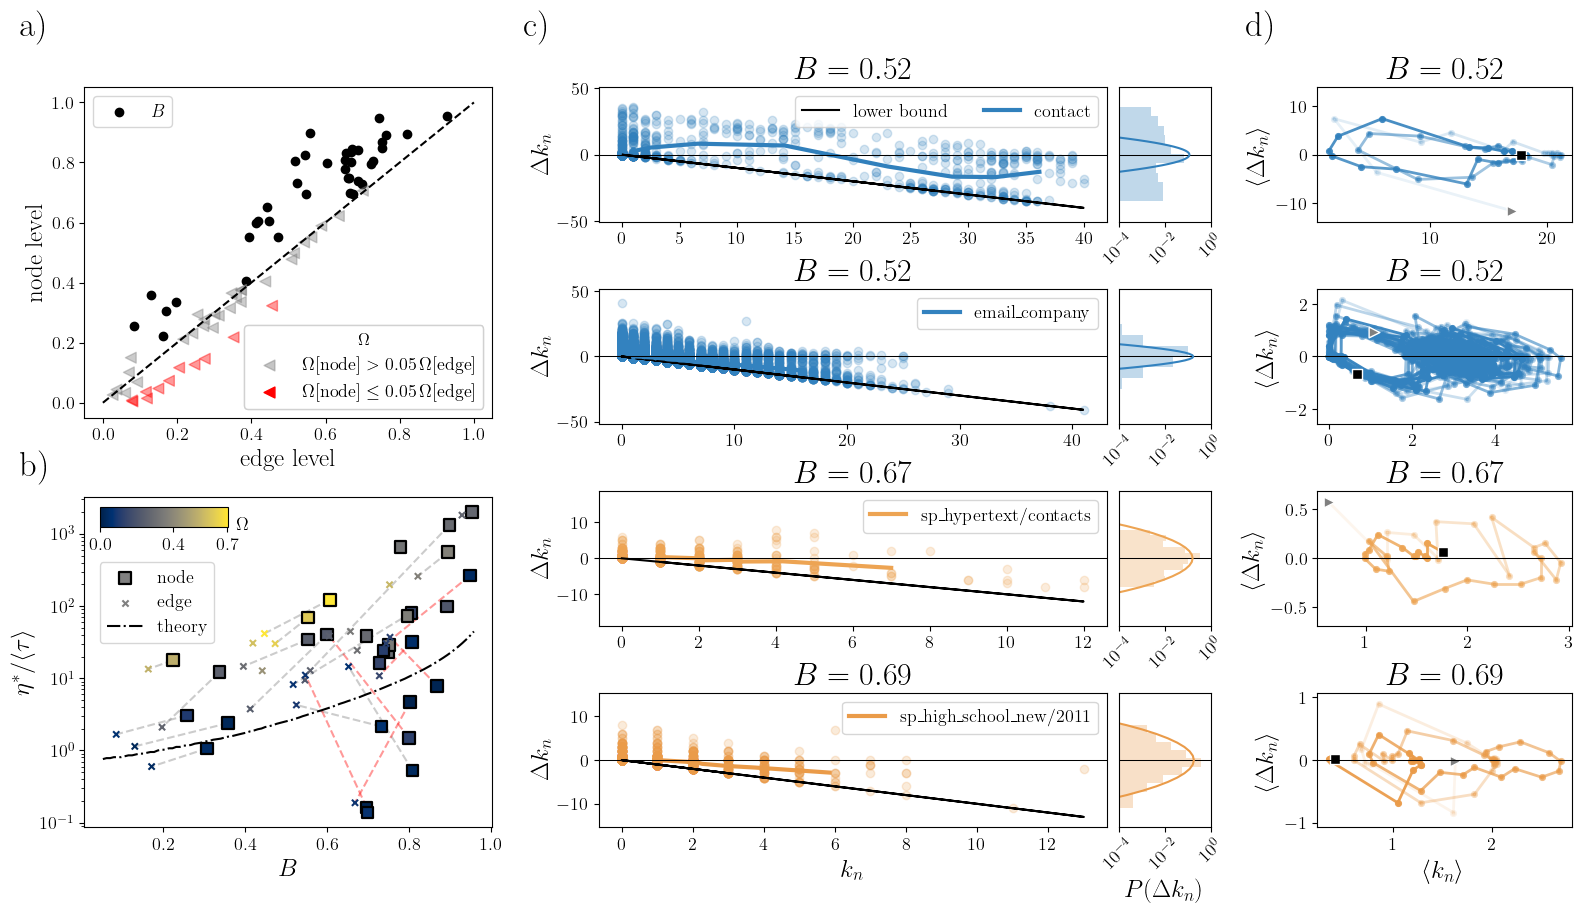

In [11]:
fig = plt.figure(figsize=(16, 10))

# Main layout: 3 columns, one row
outer_gs = gridspec.GridSpec(1, 3, width_ratios = [0.8, 1.2, 0.5], wspace=0.25)  

# Left column
gs_a = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0], hspace=0.24)

## Panel A: effect of coarse-graining (from edge-level to node-level) on burstiness and opennes
ax_b = fig.add_subplot(gs_a[0, 0])

# mark in red the datasets that lose significant openness when coarse-graining
delta_l1 = np.array(l1_means_node) - np.array(l1_means)
color = []
for i in range(len(delta_l1)):
    if delta_l1[i] <= -0.05:
        col = 'red'
    else:
        col = 'grey'
    color.append(col)

# plot effect of coarse-graining on burstiness and openness
ax_b.scatter(Bs_edges, Bs_nodes, color = 'black')
ax_b.scatter(l1_means, l1_means_node, color = color, alpha = 0.4, marker = '<', s=60) 

# legends
black_dots = ax_b.scatter([], [], color='black', label=r'$B$')
leg1 = ax_b.legend(handles=[black_dots], loc="upper left")
ax_b.add_artist(leg1)

grey_dots = ax_b.scatter([], [], color='grey', alpha=0.4, marker = '<', s=60, label=r'$\Omega[\mathrm{node}] > 0.05\,\Omega[\mathrm{edge}]$')
red_dots = ax_b.scatter([], [], color='red', marker = '<', s=60, label=r'$\Omega[\mathrm{node}] \leq 0.05\,\Omega[\mathrm{edge}]$')
leg2 = ax_b.legend(handles=[grey_dots, red_dots], loc="lower right", title = r'$\Omega$') 
ax_b.add_artist(leg2)
ax_b.plot(np.linspace(0, 1, 50), np.linspace(0, 1, 50), color = 'k', linestyle = '--')
ax_b.set_ylabel('node level')
ax_b.set_xlabel('edge level')

# panel tag: a
fig.text(0.02, 0.9977, r'$\rm{a)}$', fontsize=25, va='top', ha='left')

## Panel B: effect of coarse-graining on the maximally dynamic scale eta^*
ax_a = fig.add_subplot(gs_a[1, 0])

eta_star_open = []
eta_star_closed = []
markers_closed = []
markers_open = []
burstiness_open = []
burstiness_closed = []
eta_star_nodes = []
eta_star_edges = []
Bs_edges = []
colors_open = []
colors_closed = []
for iter_data in range(39):

    # general dataset info
    dataset_name = all_dfs[iter_data]
    new_name = dataset_name.replace("/", "_")

    graph_list_filename = f"./data/{new_name}/{new_name}_data_graph.pkl"
    translation_dict_null_filename = f"./data/{new_name}/{new_name}_data_node_edge_translation.pkl"
    with open(graph_list_filename, 'rb') as f:
        graph_info_list = pickle.load(f)
    with open(translation_dict_null_filename, 'rb') as f:
        translation_dict = pickle.load(f)

    # node level eta^* and burstiness
    activation_filename_mean_edge = f"./data/{new_name}/{new_name}_node_Activation_probability_overlap{overlap}_MAXwindows{MAX_windows}.txt"
    x, y = read_Pplus_eta_data(activation_filename_mean_edge) 
    index_eta = np.argmax(y)
    if index_eta != len(x) - 1:
        eta_star_node = x[index_eta]
    else:
        eta_star_node = None
    node_to_edges = build_node_to_edges(translation_dict)
    nodes_now, _ = get_nodes_from_list_edge_index(list(translation_dict.values()), translation_dict, k_dict = True)
    node_iets = []
    for node in nodes_now:
        edges = node_to_edges[node]
        events = [
            event
            for e in edges
            for event in graph_info_list[e]
        ]
        if len(events) > 1:
            node_iets.extend(np.diff(np.sort(events)))
    mean_tau_node = np.mean(node_iets)

    # build eta^star (rescaled by its mean IET) and burstiness vectors for cross-corpus plot + set specific markers and colors
    if dataset_name in datasets_open_node: 
        if eta_star_node is not None:
            eta_star_open.append(eta_star_node/mean_tau_node)
            eta_star_nodes.append(eta_star_node/mean_tau_node)
            burstiness_open.append(Bs_nodes[iter_data])
            markers_open.append('o')
            colors_open.append(colors[iter_data])
        else:
            eta_star_open.append(eta_star_node)
            eta_star_nodes.append(eta_star_node)
            burstiness_open.append(Bs_nodes[iter_data])
            markers_open.append('*')
            colors_open.append(colors[iter_data])
    else:
        if eta_star_node is not None:
            eta_star_closed.append(eta_star_node/mean_tau_node)
            burstiness_closed.append(Bs_nodes[iter_data])
            markers_closed.append('o')
            colors_closed.append(colors[iter_data])
            eta_star_nodes.append(eta_star_node/mean_tau_node)
        else:
            eta_star_closed.append(eta_star_node)
            burstiness_closed.append(Bs_nodes[iter_data])
            markers_closed.append('*')
            colors_closed.append(colors[iter_data])
            eta_star_nodes.append(eta_star_node)

    # edge level eta^* and burstiness
    activation_filename_mean_edge = f"./data/{new_name}/{new_name}_edge_Activation_probability_overlap{overlap}_MAXwindows{MAX_windows}.txt"
    x, y = read_Pplus_eta_data(activation_filename_mean_edge) 
    index_eta = np.argmax(y)
    if index_eta != len(x) - 1:
        eta_star_edge = x[index_eta]
    else:
        eta_star_edge = None
    filename = f'./data/{new_name}/{new_name}_edge_interevents.pkl'
    edge_iets = {}
    with open(filename, "rb") as file:
        edge_iets = pickle.load(file)
    system_interevents = flatten_dict_and_concatenate(edge_iets)
    mean_tau_edge = mean_iet[iter_data]

    # build eta^star (rescaled by its mean IET) and burstiness vectors for cross-corpus plot
    if eta_star_edge is not None:
        eta_star_edges.append(eta_star_edge/mean_tau_edge)
    else:
        eta_star_edges.append(eta_star_edge)
    Bs_edge = get_system_burstiness(system_interevents)
    Bs_edges.append(Bs_edge)

# connect the edge-level data and the node-level data with a dashed line. Mark in red the datasets that lose significant openness when coarse-graining
delta_l1 = np.array(l1_means_node) - np.array(l1_means)
for x1, y1, x2, y2, delta in zip(Bs_nodes, eta_star_nodes, Bs_edges, eta_star_edges, delta_l1):
    if y1 is None or y2 is None:
        continue
    color = 'red' if delta <= -0.05 else 'grey'
    ax_a.plot([x1, x2], [y1, y2], color=color, linestyle='--', alpha = 0.4, zorder=1)

# plot node-level and edge-level data
cmap = plt.get_cmap('cividis')
norm = mcolors.Normalize(vmin=np.min(l1_means_node), vmax=np.max(l1_means_node))
ax_a.scatter(Bs_nodes, eta_star_nodes, c=l1_means_node, cmap=cmap, edgecolor = 'k', norm=norm, s=70, lw = 1.6, marker = 's')
ax_a.scatter(Bs_edges, eta_star_edges, c=l1_means, cmap=cmap, norm=norm, s=20, marker = 'x')

# plot the theoretical expectation for a Gamma IET
Bs_sorted, eta_stars_sorted = sort_data(Bs_gamma, eta_stars_gamma)
ax_a.plot(Bs_sorted, eta_stars_sorted, color = 'k', linestyle = '-.')

# legend
black_squares = ax_a.scatter([], [], marker = 's', color = 'grey', label='node', edgecolor = 'k', lw = 1.6, s=70)
grey_circles = ax_a.scatter([], [], marker = 'x', color ='grey', label='edge', s=20)
dashed_line = ax_a.plot([], [], color='black', linestyle='-.', label=r'$\rm{theory}$')
ax_a.legend(bbox_to_anchor=(0.34, 0.53)) 

# colorbar
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cax = fig.add_axes([0.07, 0.48, 0.08, 0.02])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.ax.set_ylabel(r'$\Omega$', rotation=0, labelpad=10, fontsize=13)
cbar.ax.yaxis.set_label_position('right')
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.tick_params(labelsize=13)
cbar.solids.set_alpha(0.7)
cbar.set_ticks([0, 0.4, 0.7])

# axes labels
ax_a.set_xlabel(r'$B$')
ax_a.set_yscale('log')
ax_a.set_ylabel(r'$\eta^* / \langle \tau \rangle$')

# panel tag: b
fig.text(0.02, 0.5577, r'$\rm{b)}$', fontsize=25, va='top', ha='left')

## Panel C: degree correlations across consecutive windows
gs_b = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=outer_gs[1], hspace=0.5) # 4 sub-panels for 4 datasets

which = 'node' # topological level considered
which_datasets = [12, 13, 27, 28] # chosen datasets (index in all_dfs)

axes_b = []
for row in range(4):
    inner_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_b[row], width_ratios=[2.2, 0.4], wspace=0.04) # side-by-side sub-sub-panels
    ax_left = fig.add_subplot(inner_gs[0, 0]) # Delta k_n vs k_n
    ax_right = fig.add_subplot(inner_gs[0, 1]) # P(Delta k_n)

    # axes labels
    if row == 3:
        ax_left.set_xlabel(r'$k_n$')
        ax_right.set_xlabel(r'$P(\Delta k_n)$')
    else:
        ax_left.set_xlabel("")
        ax_right.set_xlabel("")

    ax_left.set_ylabel(r"$\Delta k_n$")

    ax_right.set_yticklabels([])
    ax_right.set_xticklabels(ax_right.get_xticklabels(), rotation = 45)
    ax_right.set_yticks([])

    # dataset considered
    iter_dataset = which_datasets[row]
    dataset_name = all_dfs[iter_dataset]
    new_name = dataset_name.replace("/", "_")
    color = colors[iter_dataset]

    # choice of max. dyn. scale + get the Delta k_n vs k_n data
    eta = get_chosen_eta(which, new_name, overlap, None)
    degree_degree_change_filename = f"./data/{new_name}/{new_name}_degree_degree_change_overlap{overlap}_MAXwindows{MAX_windows}_eta{eta:.2f}.txt.gz"
    degree, degree_change = read_two_col_data(degree_degree_change_filename)

    # Plot
    ax_left.plot(degree, -degree, color = 'k', label = r'$\rm{lower}$ $\rm{bound}$' if row == 0 else '') # raw data points of Delta k_n vs k_n
    plot1(ax_left, degree, degree_change, color, dataset_name) # quantile-binned average of Delta k_n vs k_n
    plot2(ax_right, degree_change, color) # P(Delta k_n)
    ax_left.axhline(y=0, color='k', lw = 0.75)
    ax_right.axhline(y=0, color='k', lw = 0.75)

    # get the theoretical P(Delta k)
    filename = f"./data/{new_name}/{new_name}_ccdf_edge_interevents.pkl"
    with open(filename, "rb") as file:
        data = pickle.load(file)
    cdf_x_values = data[:, 0]
    ccdf_vals = data[:, 1]
    ccdf_cont_spline = PchipInterpolator(cdf_x_values, ccdf_vals)
    x_cont = np.linspace(cdf_x_values[0], cdf_x_values[-1], 1000)
    ccdf_cont = ccdf_cont_spline(x_cont)
    filename = f'./data/{new_name}/{new_name}_node_degrees.pkl'
    input_dict = {}
    with open(filename, "rb") as file:
        input_dict = pickle.load(file)
    deg = np.max(np.array(list(input_dict.values())))
    mu = E0(0, x_cont, ccdf_cont)
    E_0_eta_nu = E0(eta*(1-0.9), x_cont, ccdf_cont)/mu
    dist_theo = np.zeros(2*deg + 1)
    binom = lambda i : scipy.stats.binom.pmf(i, deg, 1 - E_0_eta_nu)
    x_values = []
    y_values = []
    for deg_change in range(deg + 1):
        dist_theo[deg + deg_change] = np.array([ binom(i) * binom(i + deg_change) for i in range(deg - deg_change + 1) ]).sum()
        if deg_change:
            dist_theo[deg - deg_change] = dist_theo[deg + deg_change]
            x_values.append(- deg_change)
            y_values.append(dist_theo[deg - deg_change])
        x_values.append(deg_change)
        y_values.append(dist_theo[deg + deg_change])
    pair = sorted(zip(x_values, y_values))
    x_values_sorted, y_values_sorted = zip(*pair)
    ax_right.plot(y_values_sorted, x_values_sorted, color = color) # plot

    # adjust axes
    ymin1, ymax1 = ax_left.get_ylim()  
    ymin2, ymax2 = ax_right.get_ylim()  
    common_min = min(ymin1, ymin2)
    common_max = max(ymax1, ymax2)
    ax_left.set_ylim(common_min, common_max)
    ax_right.set_ylim(common_min, common_max)
    ax_right.set_xlim([0.0001, 1])
    
    # legend and title
    ax_left.legend(ncols = 2)
    ax_left.set_title(rf'$B = {its_s_burstiness[iter_dataset]:.2f}$') 

# panel tag: c
fig.text(0.335, 0.9977, r'$\rm{c)}$', fontsize=25, va='top', ha='left')

## Panel D: cycles

overlap = 0.9 # higher choice of overlap for finer trajectory granularity

gs_c = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=outer_gs[2], hspace=0.5) # 4 sub-panels for 4 datasets
axes_c = []

which = 'node' # topological level
which_datasets = [12, 13, 27, 28] # same datasets as in panel c

alpha_0 = 0.1 # initial transparency of the trajectory over time

for row in range(4):
    ax = fig.add_subplot(gs_c[row, 0])

    # axes labels
    ax.set_ylabel(r"$\langle \Delta k_n \rangle$")
    if row == 3:
        ax.set_xlabel(r"$\langle k_n \rangle$")
    else:
        ax.set_xlabel("")
    axes_c.append(ax)

    # dataset considered
    iter_dataset = which_datasets[row]
    dataset_name = all_dfs[iter_dataset]
    new_name = dataset_name.replace("/", "_")
    color = colors[iter_dataset]

    # choice of max. dyn. scale + get the <Delta k_n> vs <k_n data>
    eta = get_chosen_eta(which, new_name, overlap, 15)
    mean_pop_degree_degree_change_filename = f"./data/{new_name}/{new_name}_mean_pop_degree_degree_change_overlap{overlap}_MAXwindows{MAX_windows}_eta{eta:.2f}.txt.gz"
    mean_pop_degree, mean_pop_degree_change = read_two_col_data(mean_pop_degree_degree_change_filename)

    # Plot with increasing opacity over time
    delta_alpha = overlap/(len(mean_pop_degree) - 1)
    alpha_previous = alpha_0
    for i in range(len(mean_pop_degree) - 1):
        ax.plot(mean_pop_degree[i:i+2], mean_pop_degree_change[i:i+2], color=colors[iter_dataset], linewidth=2, alpha = alpha_previous, label = '') 
        if i > 0:
            ax.scatter(mean_pop_degree[i], mean_pop_degree_change[i], color=colors[iter_dataset], linewidth=2, alpha = alpha_previous, s = 10)
        alpha_previous += delta_alpha # increase the opacity at each time step

    # special markers for the first and last windows
    ax.scatter(mean_pop_degree[0], mean_pop_degree_change[0], color='grey', linewidth=1, marker = '>', s= 60, edgecolors='white', zorder = 2)
    ax.scatter(mean_pop_degree[len(mean_pop_degree)-1], mean_pop_degree_change[len(mean_pop_degree)-1], color='k', edgecolors='white', s= 60, marker = 's', lw = 1, zorder = 2) 

    # adjust axes and title
    ax.axhline(y = 0, color = 'k', lw = 0.75)
    lim = max(np.abs(np.max(mean_pop_degree_change)), np.abs(np.min(mean_pop_degree_change)))
    ax.set_ylim([-lim*1.2, lim*1.2])
    ax.set_title(rf'$B = {its_s_burstiness[iter_dataset]:.2f}$')  

# panel tag: d
fig.text(0.786, 0.9977, r'$\rm{d)}$', fontsize=25, va='top', ha='left')
    
fig.subplots_adjust(left=0.06, right=0.99, bottom=0.18, top=0.92)

# plt.savefig("workinprogress_figure4_v6.pdf", bbox_inches='tight', pad_inches=0.05)
plt.show()